# Mục 4: SETAR / TAR — Chuỗi log-return của bạc XAG/USD

Notebook triển khai **SETAR hai chế độ**, một trường hợp của TAR trong đó biến ngưỡng là chính return trễ. Mục tiêu: ước lượng ngưỡng, diễn giải hai phương trình và đánh giá dự báo một bước so với AR tuyến tính, Mean và Zero.

$$r_t=\begin{cases}c_L+\sum_{j=1}^{p}\phi_{L,j}r_{t-j}+\varepsilon_t,&r_{t-d}\le\gamma,\\c_H+\sum_{j=1}^{p}\phi_{H,j}r_{t-j}+\varepsilon_t,&r_{t-d}>\gamma.\end{cases}$$

Ở đây $r_t=100\log(P_t/P_{t-1})$, nên return và ngưỡng có đơn vị phần trăm. `Low/High` là dưới/trên ngưỡng của return trễ; không phải chế độ biến động thấp/cao.

**Tài liệu:** Cryer & Chan (2008), chương 15 *Threshold Models*, pp. 383–422 ([DOI](https://doi.org/10.1007/978-0-387-75959-3)); [tsDyn SETAR](https://search.r-project.org/CRAN/refmans/tsDyn/html/setar.html); [tsDyn selection](https://search.r-project.org/CRAN/refmans/tsDyn/html/selectSETAR.html). Đây là triển khai Python CLS của dự án, không phải bản sao lệnh TSA/tsDyn.

## 1. Môi trường và đường dẫn

Chạy `python -m pip install -r requirements.txt` từ thư mục gốc nếu chưa có thư viện. Notebook có thể mở từ thư mục gốc hoặc `code/`. Dữ liệu đã tiền xử lý và chia theo notebook 01/02 được đọc trực tiếp từ repo.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image
from io import BytesIO

CURRENT_DIR = Path.cwd()
BASE_DIR = CURRENT_DIR.parent if CURRENT_DIR.name == "code" else CURRENT_DIR
if not (BASE_DIR / "code" / "setar_tar.py").exists():
    raise FileNotFoundError("Mở notebook từ thư mục gốc repo hoặc code/.")
if str(BASE_DIR / "code") not in sys.path:
    sys.path.insert(0, str(BASE_DIR / "code"))
from setar_tar import load_splits, select_models, evaluate, save_tables
from setar_figures import make_figures, write_results_note

## 2. Đọc dữ liệu theo thời gian

Train: 2010–2024; validation: 2025; test: 2026 đến hết tháng 8. Không xáo trộn dữ liệu và không dùng test để chọn cấu hình. Return đầu validation/test vẫn sử dụng giá đóng cửa phiên ngay trước đó, thông tin đã biết tại thời điểm dự báo.

In [2]:
splits = load_splits(BASE_DIR)
split_summary = pd.DataFrame([
    {"Split": name, "n": len(frame), "Start": frame.Date.min(), "End": frame.Date.max()}
    for name, frame in splits.items()
])
display(split_summary)

,Split,n,Start,End
0,train,3870,2010-01-05,2024-12-31
1,validation,258,2025-01-02,2025-12-31
2,test,172,2026-01-02,2026-08-31


## 3. Ước lượng và chọn cấu hình

- Dò bậc `p=1..10`, độ trễ ngưỡng `d=1..5`, cùng bậc p trong hai chế độ.
- Với mỗi cặp `(p,d)`, dựng 71 ngưỡng từ phân vị 15%–85% trên **train**, chọn ngưỡng có SSR train thấp nhất và ước lượng hai phương trình bằng CLS.
- Mỗi chế độ phải có ít nhất 15% quan sát và `5*(p+1)` quan sát; dùng chung 10 lag đầu làm phần khởi tạo.
- Chọn `(p,d)` bằng RMSE validation. AR cũng chọn bậc theo RMSE validation.
- `train_bic` chỉ tham khảo, không dùng kết quả test để chọn mô hình.

In [3]:
selected, validation_grid, threshold_profiles = select_models(splits)
display(validation_grid.sort_values(["Model", "RMSE"]).groupby("Model").head(5).reset_index(drop=True))
s = selected["SETAR"]
print(f"SETAR chọn được: p={s.p}, d={s.d}, ngưỡng train={s.threshold:.6f}%")
print(f"AR đối chứng: p={selected['AR'].p}")

SETAR chọn được: p=4, d=4, ngưỡng train=1.072667%
AR đối chứng: p=3


,Model,p,d,threshold,train_rss,train_bic,RMSE,MAE,Bias_actual_minus_forecast,Direction_accuracy
0,AR,3,NaN,NaN,12575.470134,4600.264457,2.009686,1.436502,0.331419,0.484496
1,AR,4,NaN,NaN,12574.939549,4608.360014,2.009955,1.436920,0.333510,0.500000
2,AR,6,NaN,NaN,12573.927547,4624.566203,2.010141,1.437215,0.335442,0.507752
3,AR,5,NaN,NaN,12574.015716,4616.334847,2.010237,1.437139,0.336273,0.496124
4,AR,2,NaN,NaN,12575.977121,4592.161649,2.010808,1.436750,0.329185,0.500000
5,SETAR,4,4.0,1.072667,12535.293591,4645.721612,1.983621,1.433983,0.323865,0.515504
6,SETAR,5,4.0,1.072667,12534.513842,4661.998341,1.983963,1.434536,0.326539,0.527132
7,SETAR,3,4.0,1.072667,12540.456092,4630.794132,1.985030,1.435160,0.321902,0.480620
8,SETAR,2,4.0,1.072667,12540.880106,4614.407798,1.986035,1.435495,0.319893,0.472868
9,SETAR,2,2.0,1.268046,12515.984712,4606.737544,1.989355,1.424201,0.325253,0.503876


## 4. Refit và dự báo test

Khóa p,d sau validation. Ước lượng lại ngưỡng/hệ số từ train+validation. Giữ cố định tham số trong test và dự báo một bước với các lag đã quan sát đến t−1. Đây là đánh giá tuần tự từng phiên, không phải dự báo toàn bộ 172 phiên từ ngày đầu tiên.

Mean = trung bình tập ước lượng; Zero = return 0. RMSE và MAE dùng điểm phần trăm; không dùng MAPE trên chuỗi có thể bằng/gần 0.

In [4]:
evaluation = evaluate(splits, selected)
tables, config = save_tables(BASE_DIR, splits, selected, validation_grid, threshold_profiles, evaluation)
display(evaluation["metrics"])
final = evaluation["SETAR"]
print(f"Ngưỡng sau refit: {final.threshold:.6f}%")
print(f"Số quan sát fit: Low={final.n_low}, High={final.n_high}")
display(tables["coefficients.csv"])
display(tables["regime_summary.csv"])

Ngưỡng sau refit: 1.050277%
Số quan sát fit: Low=3212, High=906


/root/.local/lib/python3.12/site-packages/statsmodels/stats/diagnostic.py:997: FutureWarning: acorr_lm currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  return acorr_lm(


,Split,Model,n,RMSE,MAE,Bias_actual_minus_forecast,Direction_accuracy
0,validation,Zero,258,2.014185,1.437107,0.351777,NaN
1,validation,Mean,258,2.011941,1.435058,0.338695,0.581395
2,validation,AR,258,2.009686,1.436502,0.331419,0.484496
3,validation,SETAR,258,1.983621,1.433983,0.323865,0.515504
4,test,Zero,172,4.636073,3.059508,-0.042660,NaN
5,test,Mean,172,4.636515,3.055924,-0.076911,0.552326
6,test,AR,172,4.662725,3.078517,-0.074099,0.465116
7,test,SETAR,172,4.786064,3.140517,-0.089025,0.441860


,Fit_data,Model,Regime,Term,Estimate
0,train,AR,All,Intercept,0.011062
1,train,AR,All,lag_1,0.018931
2,train,AR,All,lag_2,0.013137
3,train,AR,All,lag_3,-0.006349
4,train,SETAR,Low,Intercept,-0.016067
5,train,SETAR,Low,lag_1,0.048681
6,train,SETAR,Low,lag_2,0.002557
7,train,SETAR,Low,lag_3,-0.005595
8,train,SETAR,Low,lag_4,-0.028717
9,train,SETAR,High,Intercept,0.067693


,Split,Regime,n,Actual_mean,Actual_std,RMSE,MAE,Bias_actual_minus_forecast,Direction_accuracy
0,test,High,73,-0.639265,5.334299,5.565637,3.463700,-0.657336,0.424658
1,test,Low,99,0.397261,4.043928,4.117751,2.902211,0.330032,0.454545
2,validation,High,76,0.536223,2.427780,2.392364,1.670800,0.482407,0.500000
3,validation,Low,182,0.274756,1.773095,1.785453,1.335092,0.257660,0.521978


## 5. Chẩn đoán phần dư

Ljung–Box trên phần dư và bình phương phần dư; ARCH-LM với 10 lag. Các chẩn đoán sau chọn ngưỡng là thăm dò, chưa phải kiểm định chính thức về sự tồn tại ngưỡng. Ljung–Box sử dụng `model_df=0` và chưa điều chỉnh cho tìm kiếm mô hình. ARCH của chuỗi ban đầu không tự chứng minh SETAR là mô hình đúng của trung bình có điều kiện.

In [5]:
display(tables["residual_diagnostics.csv"])
display(evaluation["predictions"].query("Split == 'test'").head(10))

,Model,Test,Lag,Statistic,p_value
0,AR,Ljung-Box residual,5,0.293056,9.977717e-01
1,AR,Ljung-Box squared residual,5,387.036162,1.844902e-81
2,AR,Ljung-Box residual,10,1.259111,9.995103e-01
3,AR,Ljung-Box squared residual,10,471.730530,4.817902e-95
4,AR,Ljung-Box residual,20,23.418725,2.687049e-01
5,AR,Ljung-Box squared residual,20,584.843467,4.474111e-111
6,AR,ARCH-LM residual,10,273.359401,6.548886e-53
7,SETAR,Ljung-Box residual,5,0.110819,9.997910e-01
8,SETAR,Ljung-Box squared residual,5,369.367941,1.181139e-77
9,SETAR,Ljung-Box residual,10,1.907614,9.970004e-01


,Date,actual_return,actual_close,Zero,Mean,AR,threshold_variable,SETAR_regime,SETAR,previous_close,Zero_price_point,Mean_price_point,AR_price_point,SETAR_price_point,Split
258,2026-01-02,1.293473,72.5600,0.0,0.03425,0.241464,8.779877,High,0.967738,71.6275,71.6275,71.652037,71.800663,72.324031,test
259,2026-01-05,5.429423,76.6085,0.0,0.03425,-0.209832,-8.363805,Low,0.162830,72.5600,72.5600,72.584856,72.407906,72.678246,test
260,2026-01-06,5.894585,81.2600,0.0,0.03425,0.202911,5.539467,High,-0.351341,76.6085,76.6085,76.634743,76.764105,76.339815,test
261,2026-01-07,-3.851213,78.1900,0.0,0.03425,0.231183,-6.242030,Low,0.504778,81.2600,81.2600,81.287837,81.448077,81.671220,test
262,2026-01-08,-1.558312,76.9810,0.0,0.03425,0.096949,1.293473,High,0.850641,78.1900,78.1900,78.216785,78.265841,78.857953,test
263,2026-01-09,3.634074,79.8300,0.0,0.03425,-0.172079,5.429423,High,-0.150496,76.9810,76.9810,77.007371,76.848646,76.865234,test
264,2026-01-12,6.466769,85.1630,0.0,0.03425,0.071177,5.894585,High,-0.416288,79.8300,79.8300,79.857347,79.886841,79.498368,test
265,2026-01-13,2.072017,86.9460,0.0,0.03425,0.221000,-3.851213,Low,0.482400,85.1630,85.1630,85.192174,85.351418,85.574819,test
266,2026-01-14,7.025416,93.2740,0.0,0.03425,0.194280,-1.558312,Low,0.167018,86.9460,86.9460,86.975785,87.115083,87.091337,test
267,2026-01-15,-0.958759,92.3840,0.0,0.03425,0.077086,3.634074,High,-0.459028,93.2740,93.2740,93.305952,93.345929,92.846828,test


## 6. Đồ thị

Lưới validation; đường SSR theo ngưỡng; chế độ test; dự báo test; RMSE/MAE; sai số tích lũy và chẩn đoán phần dư. Đồ thị dự báo có thêm panel phóng đại vì dự báo return thường nhỏ hơn nhiều so với biến động thực tế.

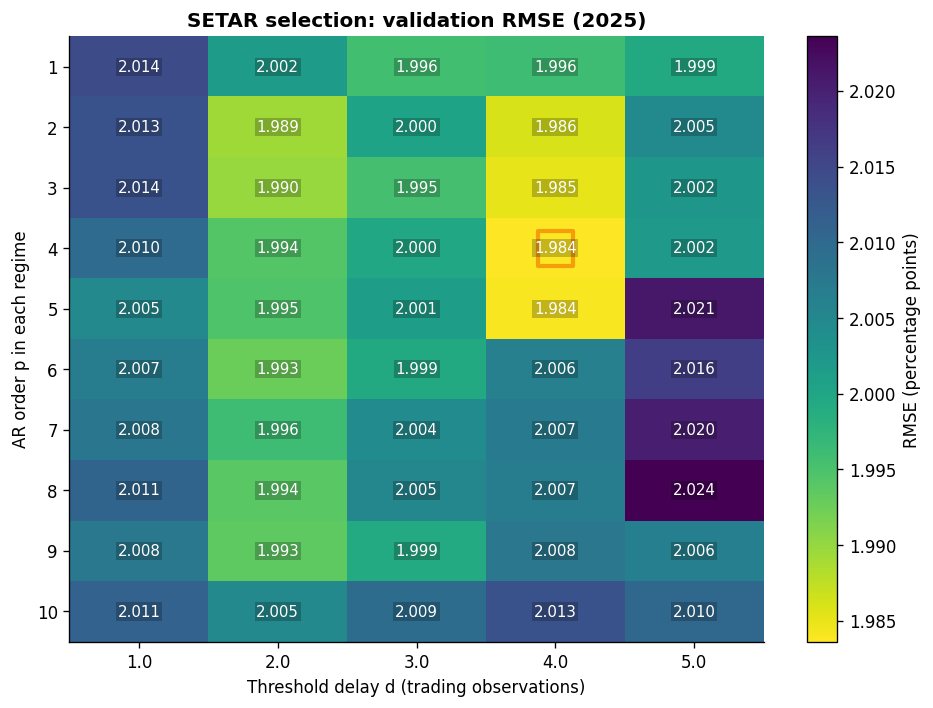

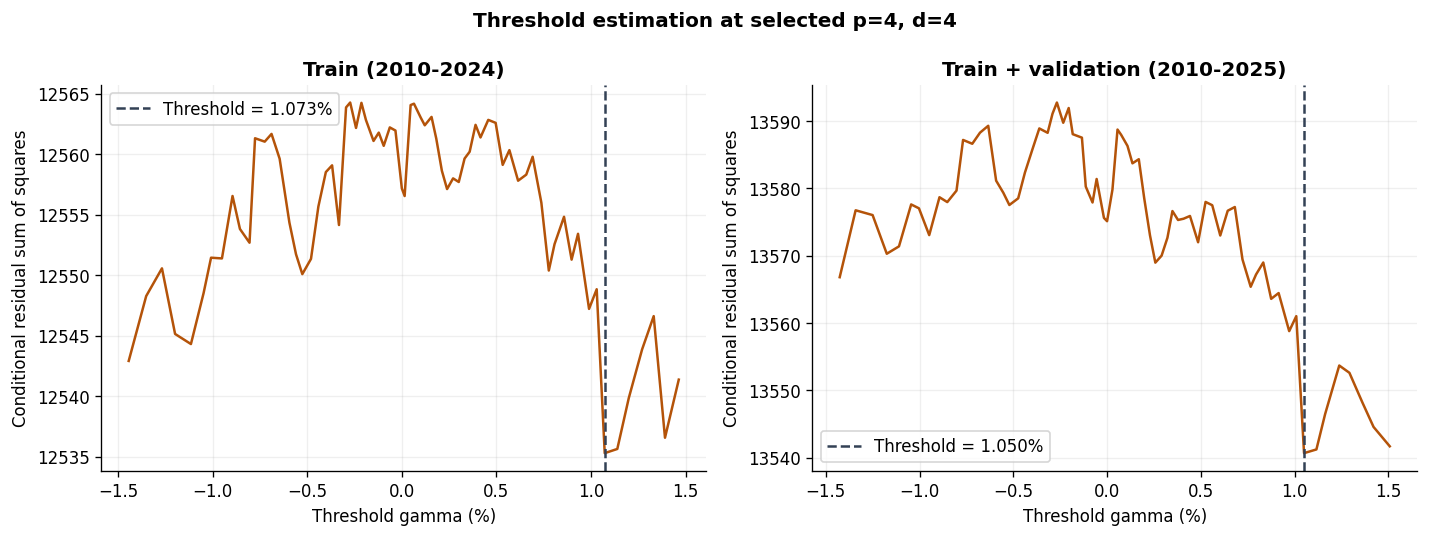

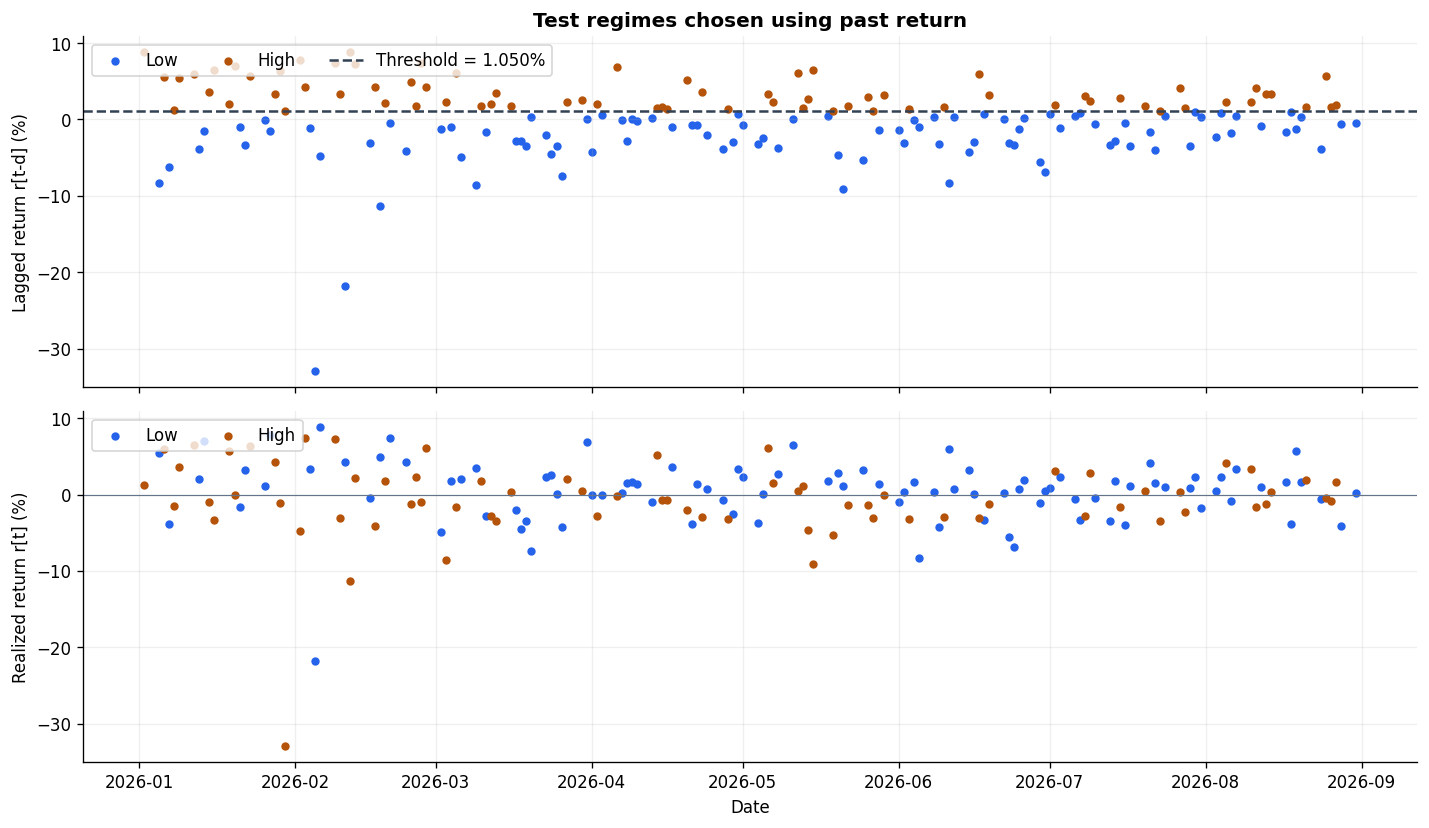

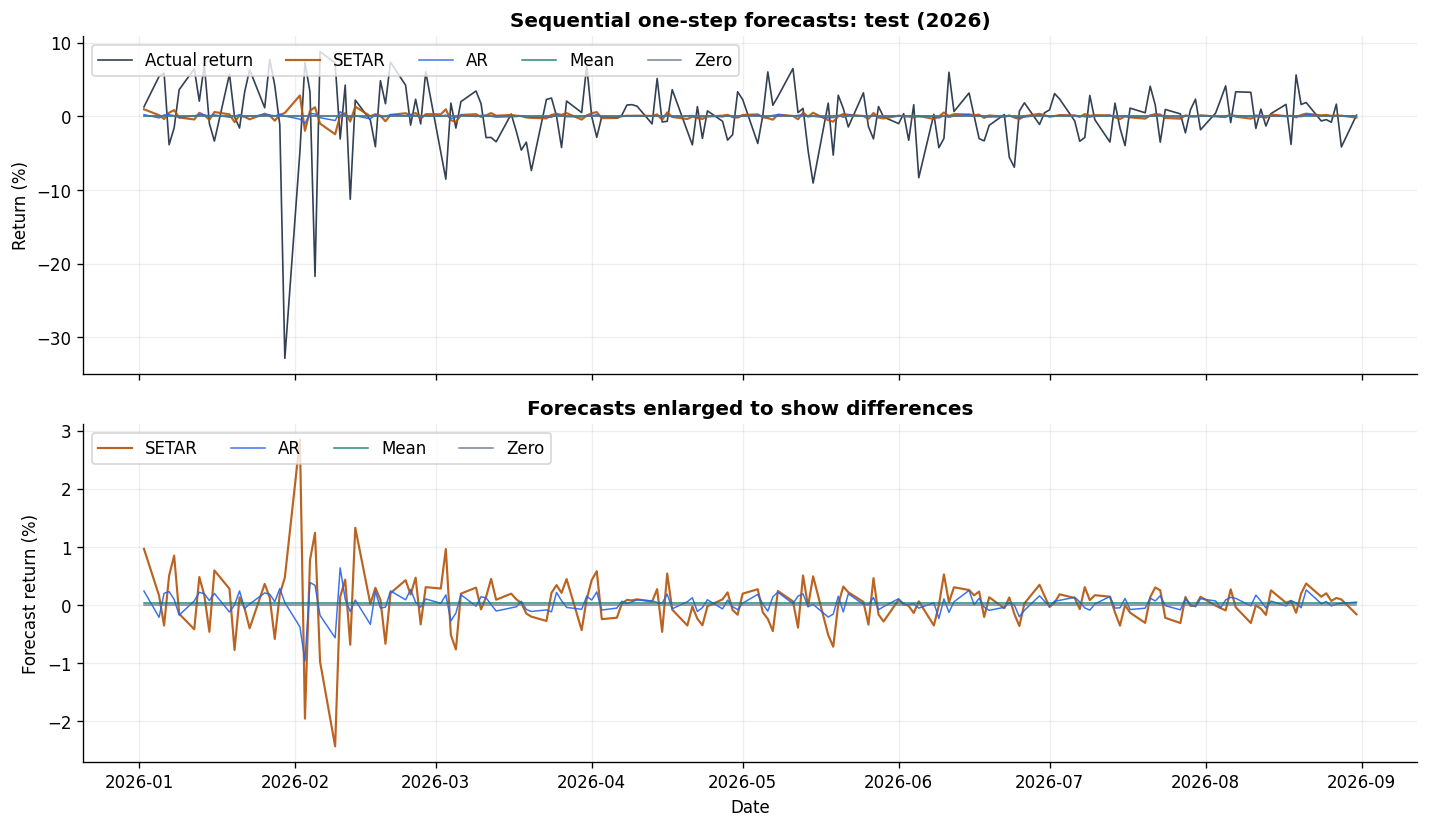

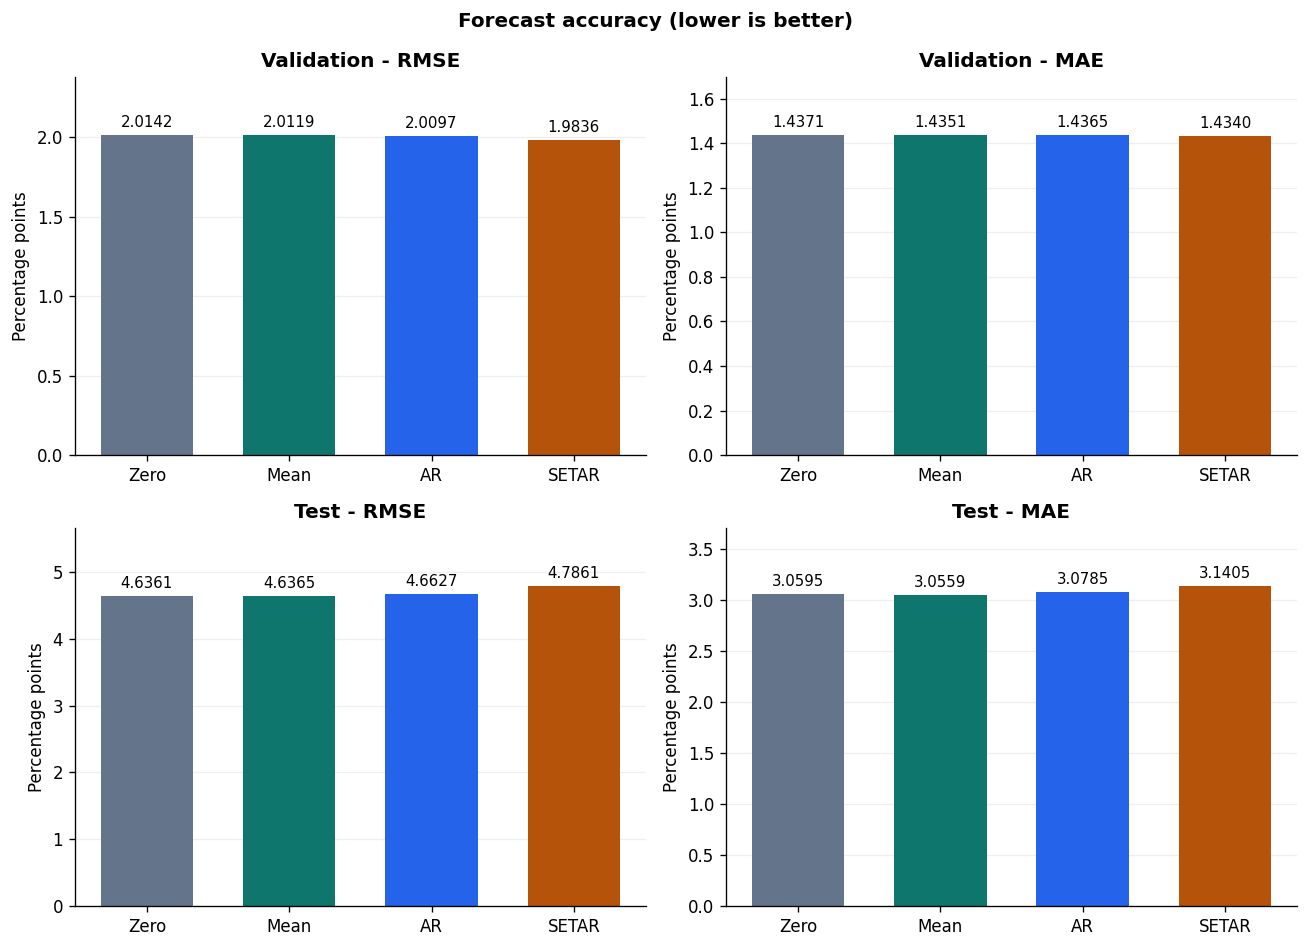

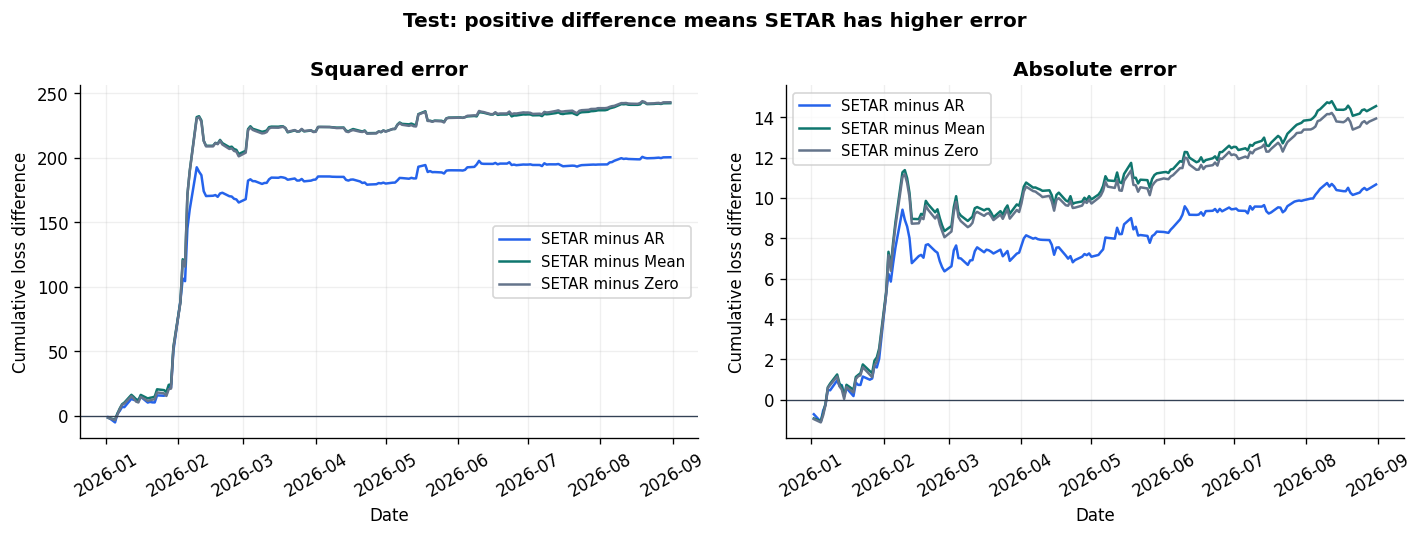

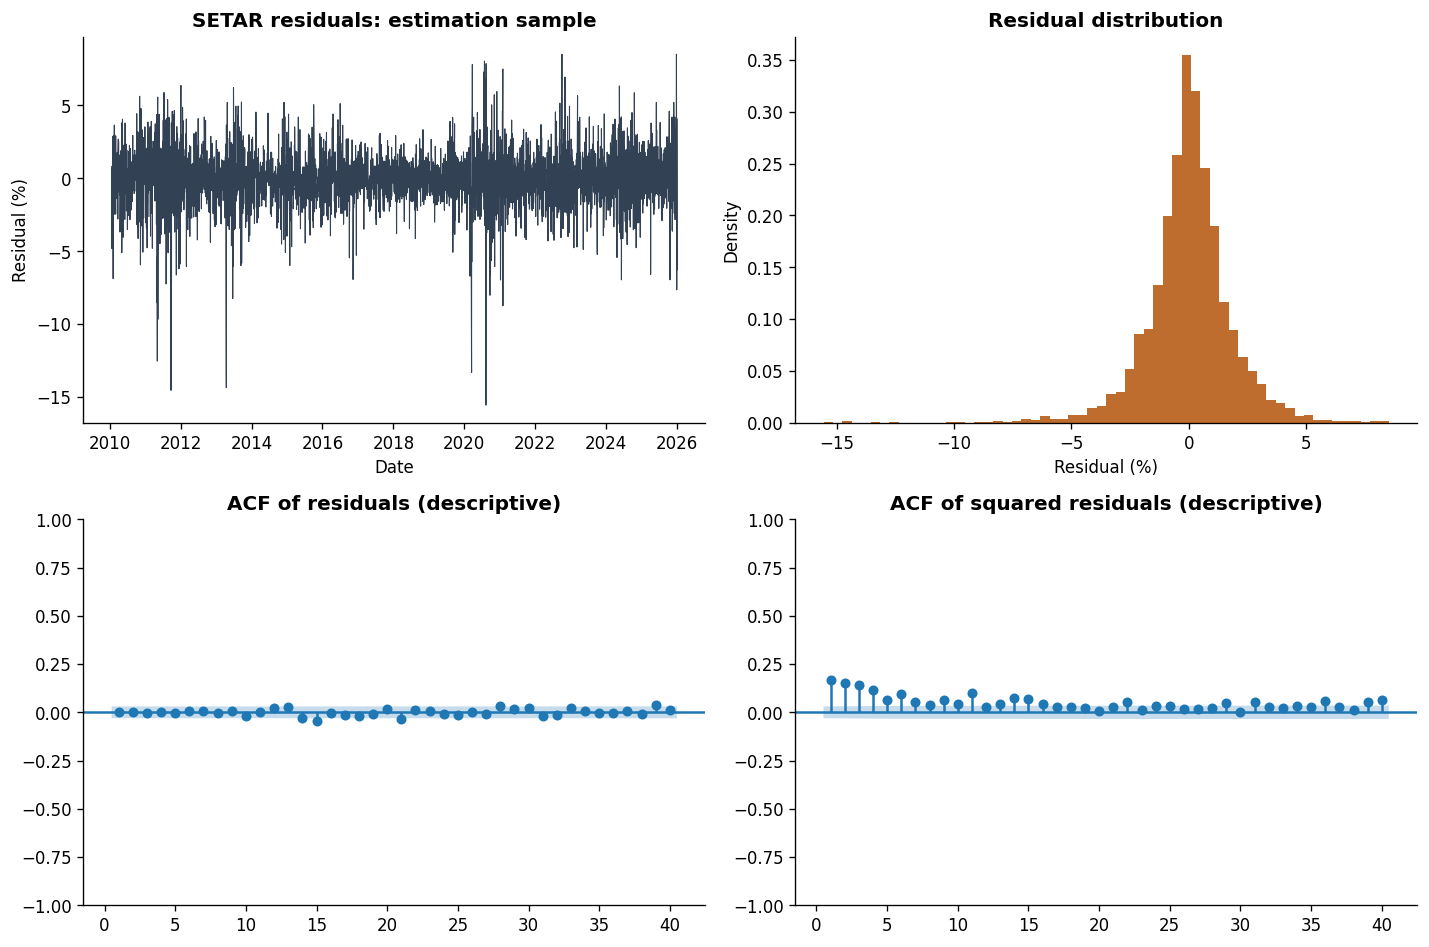

In [6]:
figures = make_figures(BASE_DIR, splits, selected, validation_grid, threshold_profiles, evaluation, tables)
for fig in figures:
    buffer = BytesIO()
    fig.savefig(buffer, format="png", dpi=120, bbox_inches="tight")
    display(Image(data=buffer.getvalue()))
    plt.close(fig)

## 7. Kết luận và tài liệu kết quả

Bảng validation là kết quả dùng để chọn cấu hình, vì vậy chỉ test mới phản ánh đánh giá cuối cùng của giao thức này. Một giai đoạn test và một mức cải thiện nhỏ chưa đủ để kết luận lợi thế ổn định. Phép đổi dự báo return sang giá chỉ tạo điểm dự báo, chưa hiệu chỉnh Jensen để tính kỳ vọng giá.

In [7]:
note = write_results_note(BASE_DIR, config, evaluation, tables)
display(Markdown(note.read_text(encoding="utf-8")))
print("Đã lưu results/setar_tar/ và figures/setar_tar/.")

Đã lưu results/setar_tar/ và figures/setar_tar/.


# Mục 4 — SETAR / TAR cho log-return của bạc XAG/USD

## Mô hình

TAR là họ mô hình tự hồi quy theo ngưỡng. SETAR là trường hợp biến ngưỡng lấy từ chính chuỗi trễ. Ở đây sử dụng SETAR hai chế độ, cùng bậc p và có hệ số chặn ở mỗi chế độ:

$$r_t=\begin{cases}c_L+\sum_{j=1}^{p}\phi_{L,j}r_{t-j}+\varepsilon_t,&r_{t-d}\le\gamma,\\c_H+\sum_{j=1}^{p}\phi_{H,j}r_{t-j}+\varepsilon_t,&r_{t-d}>\gamma.\end{cases}$$

Return tính theo phần trăm: `100 * log(Close[t] / Close[t-1])`. Low/High chỉ thể hiện giá trị return trễ ở dưới/trên ngưỡng; không phải nhãn thị trường tăng/giảm hay biến động thấp/cao.

## Giao thức thực nghiệm

- Train: 2010–2024; validation: 2025; test: 02/01/2026–31/08/2026.
- Dò `p=1..10`, `d=1..5`; lưới ngưỡng gồm 71 phân vị từ 15% đến 85% của biến ngưỡng trong tập ước lượng.
- Với từng `(p,d)`, chọn ngưỡng tối thiểu hóa SSR trên train; ước lượng hai phương trình bằng bình phương tối thiểu có điều kiện.
- Mỗi chế độ có ít nhất 15% quan sát và ít nhất `5*(p+1)` quan sát. Tất cả cấu hình dùng chung mốc khởi đầu lag 10.
- Chọn `(p,d)` bằng RMSE validation. AR tuyến tính cũng chọn p bằng cùng RMSE validation.
- Sau khi khóa p,d, ước lượng lại ngưỡng và hệ số trên train+validation; giữ cố định tham số trong test.
- Dự báo từng phiên một bước trước. Tại phiên t chỉ dùng dữ liệu đã biết đến t−1; return thực tế của phiên trước được cập nhật vào lag.
- Mean dự báo bằng trung bình tập ước lượng; Zero dự báo return bằng 0. Đây là các đối chứng riêng, không tham gia chọn cấu hình SETAR.
- RMSE/MAE tính bằng điểm phần trăm. Không dùng MAPE cho return vì return có thể bằng/gần 0.

## Cấu hình chọn được

- SETAR chọn trên validation: p=4, d=4, ngưỡng train = 1.072667%.
- Sau refit: ngưỡng = 1.050277%; số quan sát fit: 4,118; Low=3,212, High=906.
- AR đối chứng: p=3.

## Kết quả dự báo

| Tập | Mô hình | n | RMSE | MAE | Đúng dấu |
|---|---|---:|---:|---:|---:|
| validation | Zero | 258 | 2.014185 | 1.437107 | Không áp dụng |
| validation | Mean | 258 | 2.011941 | 1.435058 | 58.14% |
| validation | AR | 258 | 2.009686 | 1.436502 | 48.45% |
| validation | SETAR | 258 | 1.983621 | 1.433983 | 51.55% |
| test | Zero | 172 | 4.636073 | 3.059508 | Không áp dụng |
| test | Mean | 172 | 4.636515 | 3.055924 | 55.23% |
| test | AR | 172 | 4.662725 | 3.078517 | 46.51% |
| test | SETAR | 172 | 4.786064 | 3.140517 | 44.19% |

Zero không đưa ra dự báo hướng tăng/giảm, nên Direction_accuracy để trống trong CSV và không áp dụng trong bảng trên.

## Nhận xét

- RMSE test của SETAR cao hơn AR 2.645%.
- RMSE test của SETAR cao hơn Mean 3.225%.
- RMSE test của SETAR cao hơn Zero 3.235%.

Các chênh lệch trên là kết quả mô tả của một giai đoạn test, chưa phải chứng minh lợi thế ổn định hay khác biệt có ý nghĩa thống kê. Mô hình ngưỡng linh hoạt hơn không bảo đảm dự báo tốt hơn.

Hiệu ứng ARCH trong dữ liệu ban đầu chỉ liên quan tới phương sai có điều kiện; không phải kiểm định chứng minh phương trình trung bình có ngưỡng. Phần này chưa thực hiện kiểm định tuyến tính đối lập SETAR với phân phối null/ bootstrap phù hợp cho ngưỡng chưa xác định dưới H0.

## Chẩn đoán và giới hạn

`residual_diagnostics.csv` chứa Ljung–Box cho phần dư, bình phương phần dư và ARCH-LM trên train+validation. Ljung–Box dùng `model_df=0`; đây là chẩn đoán thăm dò sau chọn mô hình, không phải kiểm định chính thức đã điều chỉnh bậc tự do và quá trình tìm ngưỡng. ARCH-LM dùng số hệ số hồi quy để điều chỉnh ddof.

`train_bic` trong lưới chỉ là tiêu chí tham khảo Gaussian với phương sai chung, đếm cả hệ số, ngưỡng và phương sai. Việc lựa chọn cuối cùng dựa vào validation RMSE. Nếu phần dư còn ARCH, SETAR ở đây chưa mô hình hóa phương sai động.

Dự báo giá trong `forecasts.csv` là phép biến đổi `Close[t-1]*exp(predicted_return/100)`, không phải kỳ vọng có điều kiện của giá vì chưa hiệu chỉnh Jensen. Chỉ dùng return để xếp hạng mô hình.

Lưới ngưỡng hữu hạn có thể bỏ qua cực tiểu giữa các điểm; phạm vi p,d được đặt trước. Chưa xét bậc khác nhau giữa hai chế độ, ba chế độ hoặc dự báo nhiều bước. Dữ liệu cực đoan được giữ nguyên. Chẩn đoán trên từng chế độ không tự chứng minh tính dừng toàn cục của SETAR.

## Chạy lại

Từ thư mục gốc repo:

```powershell
python -m pip install -r requirements.txt
python code/run_setar_tar.py
```

Hoặc mở `code/05_mo_hinh_setar_tar.ipynb` và Run All. Các notebook 01/02 cũ vẫn có đường dẫn cứng D:/Chuyên đề 2; notebook 05 đọc trực tiếp dữ liệu đã chia trong repo.

## Tài liệu

1. Cryer, J. D., & Chan, K.-S. (2008). *Time Series Analysis: With Applications in R*, 2nd ed., Chapter 15: Threshold Models, pp. 383–422. Springer. https://doi.org/10.1007/978-0-387-75959-3.
2. tsDyn documentation: Self Threshold Autoregressive model. https://search.r-project.org/CRAN/refmans/tsDyn/html/setar.html.
3. tsDyn documentation: Automatic selection of SETAR hyper-parameters. https://search.r-project.org/CRAN/refmans/tsDyn/html/selectSETAR.html.

Triển khai Python dùng mô hình hai chế độ và CLS theo tài liệu; không tuyên bố tái hiện chính xác phần mềm tsDyn/TSA hay thí nghiệm gốc trong sách. Lưới, tiêu chí validation và đối chứng là thiết kế của dự án này.
